<a href="https://colab.research.google.com/github/EluChungara/INTELIGENCIA-ARTIFICIAL---SIS420/blob/main/LAB06/LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 06 - Reconstrucción Lab 01: Regresión Lineal Simple con PyTorch

## Modelo: $y = b + w \cdot x$

### 1. Descripción del Problema
Aprender la relación lineal entre los años de experiencia laboral ($x$) y el salario anual en miles de dólares ($y$) utilizando los componentes estructurales de PyTorch[cite: 4].

* **Variable de Entrada ($x$):** Años de experiencia laboral ($D_{in} = 1$).
* **Variable de Salida ($y$):** Salario anual en miles de dólares ($D_{out} = 1$)[cite: 4].
* **Muestras ($m$):** 30 pares de entrenamiento correspondientes al dataset del Laboratorio 01[cite: 4].
* **Objetivo:** Encontrar los parámetros de peso ($w$) y sesgo ($b$) que minimicen el Error Cuadrático Medio mediante Descenso por el Gradiente Estocástico (`torch.optim.SGD`).

### 2. Metodología en PyTorch
1. Graficación inicial del dataset original en dispersión 2D[cite: 4].
2. Encapsulamiento de datos mediante clases `Dataset` y `DataLoader` con mezcla aleatoria (`shuffle=True`).
3. Arquitectura lineal `nn.Linear(1, 1)`.
4. Criterio de costo `nn.MSELoss()` y optimizador estocástico `torch.optim.SGD`.
5. Guardado de pesos periódicos cada 10 épocas en carpetas de checkpoints (`torch.save`).
6. Gráfica de convergencia de costo ($J$ vs Épocas), recta ajustada con las 10 nuevas inferencias y evaluación de métricas.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Módulos de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Semillas reproducibles
np.random.seed(42)
torch.manual_seed(42)

# Dispositivo activo de cómputo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Versión de PyTorch: {torch.__version__}")
print(f"Dispositivo activo: {device}")

Versión de PyTorch: 2.11.0+cpu
Dispositivo activo: cpu


## 1. Declaración del Dataset Original y Gráfica 1 (Dispersión)

Se definen los 30 ejemplos originales emparejando los años de experiencia ($x$) con el salario ($y$) y se traza su diagrama de dispersión para observar la correlación lineal positiva.

Total de ejemplos de entrenamiento (m): 30


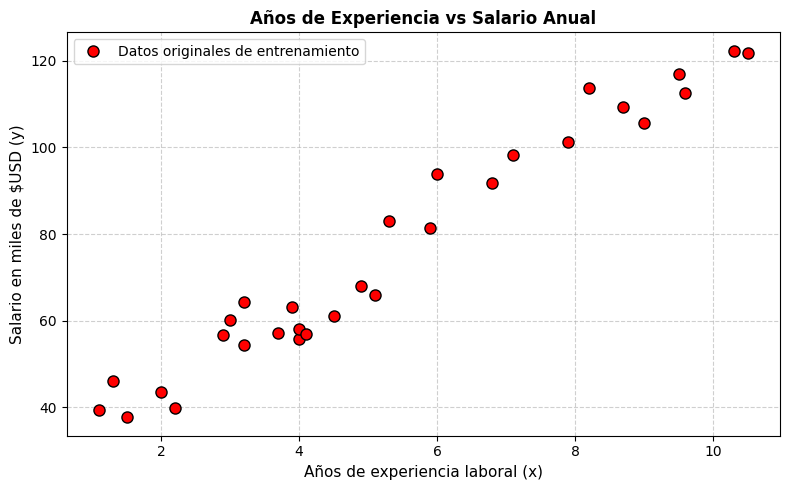

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# DATASET ORIGINAL DEL LABORATORIO 01
# ==============================================================================
X = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5,
              4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5], dtype=np.float32)

y = np.array([39.3, 46.2, 37.7, 43.5, 39.8, 56.6, 60.1, 54.4, 64.4, 57.1, 63.2, 55.7, 58.1, 57.0, 61.1,
              67.9, 66.0, 83.0, 81.3, 93.9, 91.7, 98.2, 101.3, 113.8, 109.4, 105.5, 116.9, 112.6, 122.3, 121.8], dtype=np.float32)

m = len(X)
print(f"Total de ejemplos de entrenamiento (m): {m}")

# Gráfica 1: Dispersión de los datos originales
plt.figure(figsize=(8, 5))
plt.plot(X, y, 'ro', ms=8, mec='k', label='Datos originales de entrenamiento')
plt.title('Años de Experiencia vs Salario Anual', fontsize=12, fontweight='bold')
plt.xlabel('Años de experiencia laboral (x)', fontsize=11)
plt.ylabel('Salario en miles de $USD (y)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Objetos `Dataset` y `DataLoader` en PyTorch

Se crea la clase `DatasetLinealSimple` derivada de `torch.utils.data.Dataset`. Para operar con capas lineales de PyTorch, las variables de entrada y salida se formatean con dimensiones tensoriales bidimensionales $(m, 1)$. Se configura un `DataLoader` por mini-lotes con mezcla aleatoria (`shuffle=True`).

In [ ]:
class DatasetLinealSimple(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # Dimensión (m, 1)
        self.y = torch.from_numpy(y).float().unsqueeze(1)  # Dimensión (m, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = DatasetLinealSimple(X, y)

# Batch size pequeño para asegurar convergencia estocástica sobre 30 datos
batch_size = 4
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Total de muestras : {len(dataset)}")
print(f"Lotes por época   : {len(data_loader)}")

Total de muestras : 30
Lotes por época   : 8


## 3. Definición del Modelo, Función de Costo y Optimizador

* **Modelo:** Capa lineal `nn.Linear(1, 1)` ($D_{in} = 1, D_{out} = 1$), que calcula internamente $\hat{y} = x \cdot w + b$.
* **Criterio de Costo:** Error Cuadrático Medio (`nn.MSELoss()`).
* **Optimizador:** Descenso por el Gradiente Estocástico puro `torch.optim.SGD(model.parameters(), lr=0.01)`.

In [ ]:
D_in = 1
D_out = 1

model = nn.Linear(D_in, D_out).to(device)
print("Estructura del modelo lineal:")
print(model)

criterion = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Estructura del modelo lineal:
Linear(in_features=1, out_features=1, bias=True)


## 4. Bucle de Entrenamiento y Guardado Periódico de Checkpoints

Se entrena el modelo durante 80 épocas. Cada 10 épocas se resguardan los pesos (`state_dict`) en carpetas dedicadas usando `torch.save` y `os.makedirs`, registrando el descenso medio de la función de pérdida.

In [ ]:
epochs = 80
historial_loss = []
directorio_checkpoints = "./checkpoints_lab01"
os.makedirs(directorio_checkpoints, exist_ok=True)

model.train()
for epoch in range(1, epochs + 1):
    acum_loss = []

    for x_b, y_b in data_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        # 1. Forward pass
        y_pred = model(x_b)

        # 2. Pérdida MSE
        loss = criterion(y_pred, y_b)
        acum_loss.append(loss.item())

        # 3. Limpieza de gradientes, retropropagación y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_promedio = np.mean(acum_loss)
    historial_loss.append(loss_promedio)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Época [{epoch:02d}/{epochs:02d}] - Costo Medio (MSE): {loss_promedio:.4f}")

    # Guardado de checkpoints cada 10 épocas
    if epoch % 10 == 0:
        carpeta_epoca = os.path.join(directorio_checkpoints, f"epoch_{epoch}")
        os.makedirs(carpeta_epoca, exist_ok=True)
        ruta_pt = os.path.join(carpeta_epoca, f"modelo_epoch_{epoch}.pt")
        torch.save(model.state_dict(), ruta_pt)
        print(f"  --> [Checkpoint Guardado]: {ruta_pt}")

# Guardado final de pesos
torch.save(model.state_dict(), os.path.join(directorio_checkpoints, "modelo_final.pt"))

# Extracción de parámetros aprendidos por PyTorch
w_aprendido = model.weight.item()
b_aprendido = model.bias.item()


print("             PARÁMETROS APRENDIDOS POR PYTORCH")
print("=" * 60)
print(f"Pendiente aprendida (w)     : {w_aprendido:.4f}")
print(f"Intercepción aprendida (b) : {b_aprendido:.4f}")
print(f"Ecuación de la recta        : y = {b_aprendido:.2f} + {w_aprendido:.2f} * x")


Época [01/80] - Costo Medio (MSE): 1054.2873
Época [10/80] - Costo Medio (MSE): 139.3641
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_10/modelo_epoch_10.pt
Época [20/80] - Costo Medio (MSE): 69.4886
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_20/modelo_epoch_20.pt
Época [30/80] - Costo Medio (MSE): 56.8917
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_30/modelo_epoch_30.pt
Época [40/80] - Costo Medio (MSE): 46.0592
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_40/modelo_epoch_40.pt
Época [50/80] - Costo Medio (MSE): 42.4429
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_50/modelo_epoch_50.pt
Época [60/80] - Costo Medio (MSE): 37.9141
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_60/modelo_epoch_60.pt
Época [70/80] - Costo Medio (MSE): 48.3507
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_70/modelo_epoch_70.pt
Época [80/80] - Costo Medio (MSE): 40.8042
  --> [Checkpoint Guardado]: ./checkpoints_lab01/epoch_80/modelo_epoch_

## 5. Gráfica 2: Convergencia de la Función de Costo (Entrenamiento)

Se traza la curva de aprendizaje a lo largo de las 80 épocas para verificar el descenso monótono y asintótico del Error Cuadrático Medio.

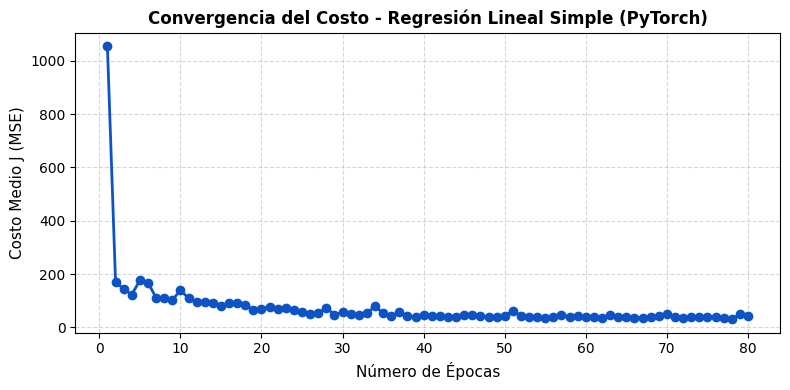

Costo inicial : 1054.2873
Costo final   : 40.8042


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(historial_loss) + 1), historial_loss, lw=2, color='#0d53c4', marker='o')
plt.xlabel('Número de Épocas', fontsize=11)
plt.ylabel('Costo Medio J (MSE)', fontsize=11)
plt.title('Convergencia del Costo - Regresión Lineal Simple (PyTorch)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Costo inicial : {historial_loss[0]:.4f}")
print(f"Costo final   : {historial_loss[-1]:.4f}")

## 6. Inferencias para los 10 Nuevos Valores de $x$

Se evalúa el modelo entrenado en modo de inferencia (`model.eval()`) sobre los mismos 10 nuevos valores no vistos de experiencia laboral de tu Laboratorio 01 original ($0.5$ a $12.0$ años), desactivando gradientes (`torch.no_grad()`).

In [ ]:
X_nuevos = np.array([0.5, 2.5, 4.3, 5.5, 6.5, 7.5, 8.5, 11.0, 11.5, 12.0], dtype=np.float32)

model.eval()
with torch.no_grad():
    tensor_nuevos = torch.from_numpy(X_nuevos).float().unsqueeze(1).to(device)
    y_nuevos_pred = model(tensor_nuevos).cpu().numpy().flatten()

print("=" * 60)
print("         INFERENCIAS PARA 10 NUEVOS VALORES DE X")
print("=" * 60)
print(f"{'Años Exp (x)':<20} | {'Salario Predicho (y)':<25}")
print("-" * 60)
for x_val, y_val in zip(X_nuevos, y_nuevos_pred):
    print(f"{x_val:<20.1f} | ${y_val:<24.2f}k USD")
print("=" * 60)

         INFERENCIAS PARA 10 NUEVOS VALORES DE X
Años Exp (x)         | Salario Predicho (y)     
------------------------------------------------------------
0.5                  | $29.45                   k USD
2.5                  | $49.13                   k USD
4.3                  | $66.84                   k USD
5.5                  | $78.65                   k USD
6.5                  | $88.49                   k USD
7.5                  | $98.33                   k USD
8.5                  | $108.17                  k USD
11.0                 | $132.77                  k USD
11.5                 | $137.69                  k USD
12.0                 | $142.61                  k USD


## 7. Gráfica 3: Recta Ajustada y las 10 Nuevas Inferencias

Se grafican superpuestos los 30 puntos de entrenamiento originales, la recta ajustada predicha por PyTorch y las 10 nuevas inferencias proyectadas.

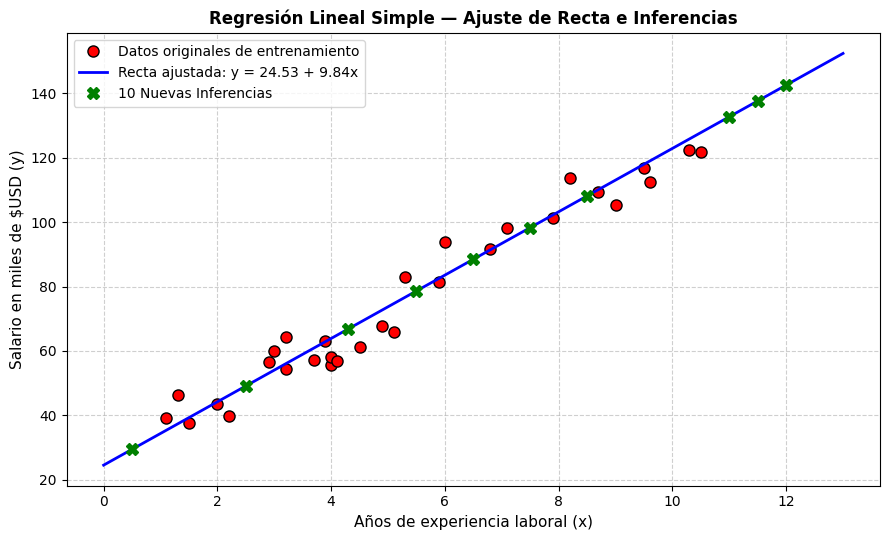

In [ ]:
# Puntos extremos para trazar la recta continua a lo largo del dominio
x_linea = np.array([0, 13], dtype=np.float32)
y_linea = b_aprendido + w_aprendido * x_linea

plt.figure(figsize=(9, 5.5))

# 1. Puntos originales del dataset
plt.plot(X, y, 'ro', ms=8, mec='k', label='Datos originales de entrenamiento')

# 2. Recta de regresión obtenida por PyTorch
plt.plot(x_linea, y_linea, 'b-', lw=2, label=f'Recta ajustada: y = {b_aprendido:.2f} + {w_aprendido:.2f}x')

# 3. Puntos de las 10 nuevas inferencias
plt.plot(X_nuevos, y_nuevos_pred, 'gX', ms=9, label='10 Nuevas Inferencias')

plt.title('Regresión Lineal Simple — Ajuste de Recta e Inferencias', fontsize=12, fontweight='bold')
plt.xlabel('Años de experiencia laboral (x)', fontsize=11)
plt.ylabel('Salario en miles de $USD (y)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()